In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import kagglehub

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from sklearn.utils.class_weight import compute_class_weight

# 1. DOWNLOAD DATASET FROM KAGGLE

path = kagglehub.dataset_download("emiliovenegas1/mammography-dataset-from-inbreast-mias-and-ddsm")
print("Path to dataset files:", path)

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 50)
    if root != path:
        break

Path to dataset files: C:\Users\dell\.cache\kagglehub\datasets\emiliovenegas1\mammography-dataset-from-inbreast-mias-and-ddsm\versions\1
Folder: C:\Users\dell\.cache\kagglehub\datasets\emiliovenegas1\mammography-dataset-from-inbreast-mias-and-ddsm\versions\1
Subfolders: ['CLAHE_images']
Files: []
--------------------------------------------------
Folder: C:\Users\dell\.cache\kagglehub\datasets\emiliovenegas1\mammography-dataset-from-inbreast-mias-and-ddsm\versions\1\CLAHE_images
Subfolders: ['benign', 'malignant', 'normal']
Files: []
--------------------------------------------------


In [2]:
# 2. FIND THE ACTUAL IMAGE DATA FOLDER

# This block searches for a folder that contains class folders:
# normal / benign / malignant

candidate_dirs = []

for root, dirs, files in os.walk(path):
    dir_names = {d.lower() for d in dirs}
    if {"normal", "benign", "malignant"}.issubset(dir_names):
        candidate_dirs.append(root)

if not candidate_dirs:
    raise FileNotFoundError(
        "Could not find a dataset folder containing 'normal', 'benign', and 'malignant' subfolders."
    )

base_dir = candidate_dirs[0]
print("Using dataset folder:", base_dir)
print("Class folders found:", os.listdir(base_dir))

Using dataset folder: C:\Users\dell\.cache\kagglehub\datasets\emiliovenegas1\mammography-dataset-from-inbreast-mias-and-ddsm\versions\1\CLAHE_images
Class folders found: ['benign', 'malignant', 'normal']


In [3]:
# 3. DATA AUGMENTATION & GENERATORS

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print("Train samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)

if train_gen.samples == 0 or val_gen.samples == 0:
    raise ValueError("No images were found. Check the folder structure inside the downloaded dataset.")

Found 21282 images belonging to 3 classes.
Found 5320 images belonging to 3 classes.
Class indices: {'benign': 0, 'malignant': 1, 'normal': 2}
Train samples: 21282
Validation samples: 5320


In [4]:
# 4. CLASS WEIGHTS

y_train = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.816058897963879), 1: np.float64(0.6467906637490882), 2: np.float64(4.376310919185688)}


In [ ]:
# 5. MODEL BUILDING & TRAINING

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_mammography_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

print("Starting training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

Starting training...


C:\Users\dell\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 318/1331 ━━━━━━━━━━━━━━━━━━━━ 20:52 1s/step - accuracy: 0.3512 - auc: 0.5270 - loss: 1.2023

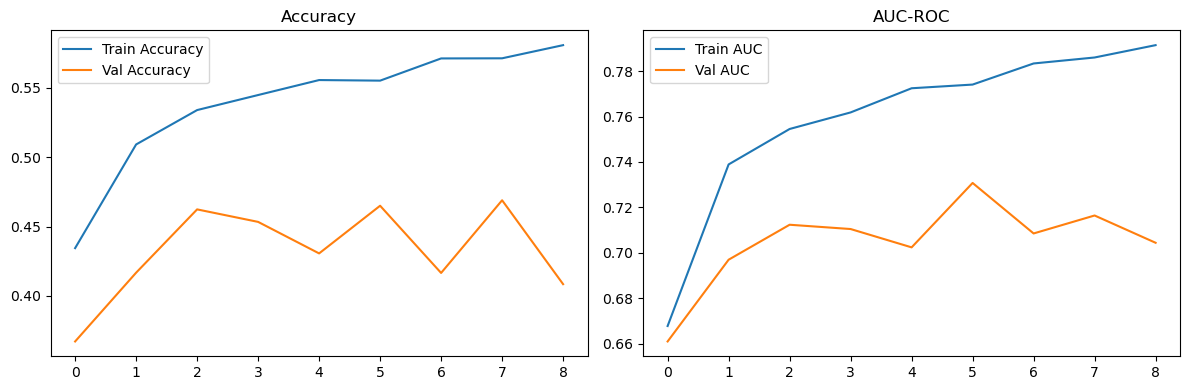

In [6]:
# 6. EVALUATION & VISUALIZATION

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.title("AUC-ROC")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 7. SINGLE IMAGE TEST

TEST_IMAGE_PATH = "trial.jpg"

def test_single_image(img_path, model, class_indices):
    img = cv2.imread(img_path)
    if img is None:
        print("Error: Could not load image. Check the path.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = img_resized.astype("float32") / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_batch, verbose=0)

    idx_to_class = {v: k for k, v in class_indices.items()}
    pred_idx = int(np.argmax(preds[0]))
    pred_class = idx_to_class[pred_idx]
    confidence = float(np.max(preds[0]) * 100)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {pred_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

test_single_image(TEST_IMAGE_PATH, model, train_gen.class_indices)